# Detecting relief in a image
This nootebook shows how can detect reliefs on an image

In [8]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Load Image test

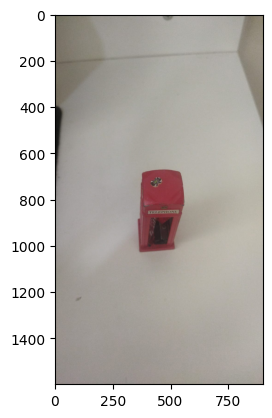

In [11]:
img = cv2.imread('../../datas/reliefs/telephone.jpg')
img_RGB = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im_RGB);

## 2. Detecting reliefs

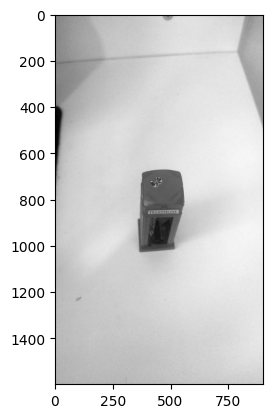

In [19]:
# change to gray scale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray');

In [20]:
# using sobel to detect possible reliefs
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=5)
sobel_mag = cv2.magnitude(sobelx, sobely)

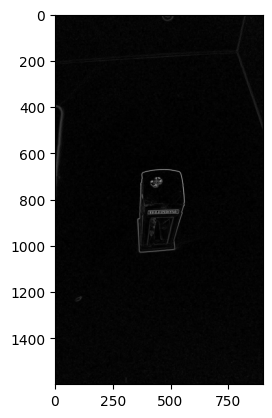

In [37]:
plt.imshow(sobel_mag, cmap='gray');

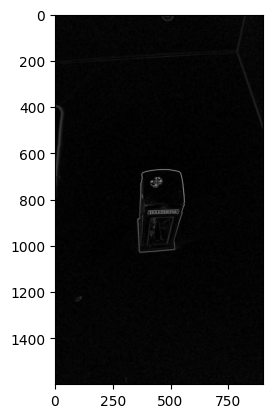

In [36]:
# normalize to best visualization
sobel_norm = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
plt.imshow(sobel_norm, cmap='gray');

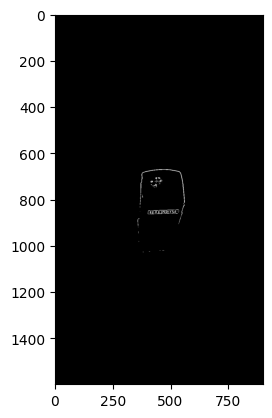

In [35]:
# Threshold to detect areas with so difference
_, elevation_mask = cv2.threshold(sobel_norm, 100, 255, cv2.THRESH_BINARY)
plt.imshow(elevation_mask, cmap='gray');

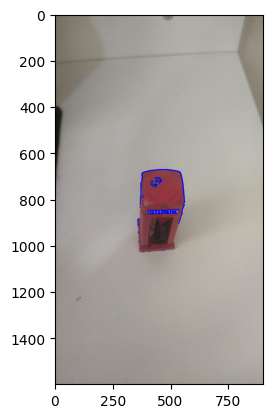

In [34]:
# detectin countourn at the relief
elevation_contours, _ = cv2.findContours(elevation_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# drawn the countours
cv2.drawContours(img, elevation_contours, -1, (255, 0, 0), 2)

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB));

### 3.1 Creating a function to become the test more easies

In [58]:
def has_relief(img):
    """
    Detect relief on a image
    Params: 
        img: on BRG scale
    returns:
        has_relief: bool
    """
    # convert to gray scale
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # using sobel to detect possible reliefs
    sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=5)
    sobel_mag = cv2.magnitude(sobelx, sobely)
    
    # Normalize to visualize
    sobel_norm = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    
    # Threshold to detect areas with so difference 
    _, elevation_mask = cv2.threshold(sobel_norm, 100, 255, cv2.THRESH_BINARY)
    
    # detect contours relief
    elevation_contours, _ = cv2.findContours(elevation_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # loop to avoid false-positeves
    for contour in elevation_contours:
        # ensure don't considered a small areas
        if cv2.contourArea(contour) > 500:
            cv2.drawContours(img, [contour], -1, (255, 0, 0), 2)
            return True
    
    return False

### 3.2 Testing with another images

Has relief:  False


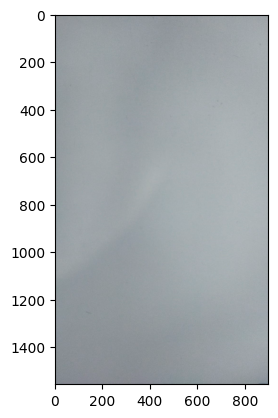

In [59]:
img = cv2.imread('../../datas/reliefs/no_relief.jpg')
# verif if has relief
print('Has relief: ', has_relief(img)) 
plt.imshow(img);

Has relief:  True


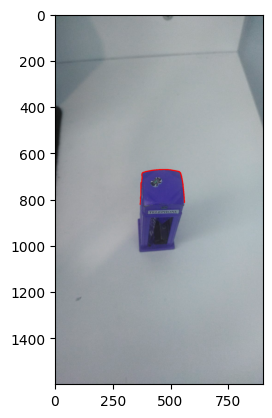

In [60]:
img = cv2.imread('../../datas/reliefs/telephone.jpg')
# verif if has relief
print('Has relief: ', has_relief(img)) 
plt.imshow(img);

Has relief:  True


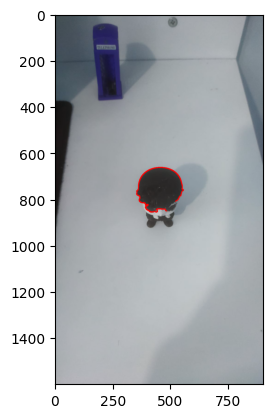

In [61]:
img = cv2.imread('../../datas/reliefs/funkopop.jpg')
# verif if has relief
print('Has relief: ', has_relief(img)) 
plt.imshow(img);

Has relief:  True


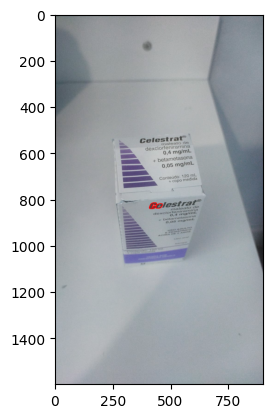

In [64]:
img = cv2.imread('../../datas/reliefs/box.jpg')
# verif if has relief
print('Has relief: ', has_relief(img)) 
plt.imshow(img);

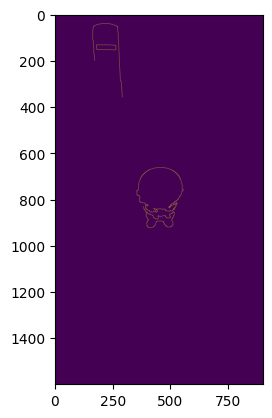

In [63]:
# Carregar a imagem
img = cv2.imread('../../datas/reliefs/funkopop.jpg')

# Pré-processamento
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Detecção de bordas
edges = cv2.Canny(blurred, 50, 150)

# Visualização
plt.imshow(img)
plt.imshow(edges)